# S5 Causal Masked Reconstruction Colab

This notebook trains a causal `S5` encoder with masked signal reconstruction on Utah-array cache shards stored in Google Drive.

Default design:

- reconstruct normalized raw patch values in `TX` space
- causal `S5` backbone with session-keyed token read-in / read-out boundaries
- patch-level masking by default with `patch_size=4`, `patch_stride=2`
- contiguous masked spans with a fixed overall mask ratio
- same held-out `Brain2Text25` frozen phoneme probe workflow used in the other `s5` notebooks


In [1]:
# Mount Drive and resolve cache / output roots.

from google.colab import drive
from pathlib import Path

drive.mount("/content/drive")

DRIVE_ROOT = Path("/content/drive/MyDrive")
cache_candidates = [
    DRIVE_ROOT / "utah_ssl" / "data" / "cache_v1",
]

CACHE_ROOT = next((p for p in cache_candidates if p.exists()), cache_candidates[0])
OUTPUT_ROOT = DRIVE_ROOT / "utah_ssl" / "outputs" / "ssl_experiments" / "masked_reconstruction"
OUTPUT_ROOT.mkdir(parents=True, exist_ok=True)

print("DRIVE_ROOT :", DRIVE_ROOT)
print("CACHE_ROOT :", CACHE_ROOT, "| exists:", CACHE_ROOT.exists())
print("OUTPUT_ROOT:", OUTPUT_ROOT, "| exists:", OUTPUT_ROOT.exists())

if CACHE_ROOT.exists():
    datasets = sorted(p.name for p in CACHE_ROOT.iterdir() if p.is_dir())
    print("datasets:", datasets)
else:
    print("cache candidates checked:")
    for path in cache_candidates:
        print(" -", path)


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
DRIVE_ROOT : /content/drive/MyDrive
CACHE_ROOT : /content/drive/MyDrive/utah_ssl/data/cache_v1 | exists: True
OUTPUT_ROOT: /content/drive/MyDrive/utah_ssl/outputs/ssl_experiments/masked_reconstruction | exists: True
datasets: ['000950', 'brain2text24', 'brain2text25', 'motor_data', 'plug_n_play', 'unsupervised_cursor_recalibration_offline', 'unsupervised_cursor_recalibration_online', 'willett_handwriting']


In [2]:
# Clone the public repo and import the reusable masked SSL helpers.

import os
import subprocess
import sys
from pathlib import Path

REPO_URL = "https://github.com/ethan-read/utah-ssl.git"
REPO_DIR = Path("/content/utah-ssl")
EXPERIMENTS_DIR = REPO_DIR / "analysis" / "active" / "ssl_experiments"
MASKED_SSL_DIR = EXPERIMENTS_DIR / "masked_ssl"
SSL_DIR = REPO_DIR / "analysis" / "active" / "transfer_benchmark" / "ssl_autoresearch"

os.chdir("/content")

if REPO_DIR.exists():
    print("Using existing repo:", REPO_DIR)
else:
    subprocess.run(["git", "clone", REPO_URL, str(REPO_DIR)], check=True)

os.chdir(REPO_DIR)

for candidate in (REPO_DIR, EXPERIMENTS_DIR, SSL_DIR):
    candidate_str = str(candidate)
    if candidate_str not in sys.path:
        sys.path.insert(0, candidate_str)

os.environ["SSL_AUTORESEARCH_CACHE_ROOT"] = str(CACHE_ROOT)
os.environ["SSL_AUTORESEARCH_OUTPUT_ROOT"] = str(OUTPUT_ROOT)

if not MASKED_SSL_DIR.exists():
    raise FileNotFoundError(
        "The cloned repo does not contain analysis/active/ssl_experiments/masked_ssl. "
        "Make sure REPO_DIR points at a checkout that includes the masked reconstruction package."
    )

from masked_ssl import (
    CacheAccessConfig,
    DownstreamProbeConfig,
    SSLTrainingConfig,
    build_random_init_probe_state,
    build_segment_sampler,
    list_ssl_checkpoints,
    load_precomputed_session_feature_stats_into_cache_context,
    plot_ssl_training_history,
    prepare_cache_context,
    recover_downstream_probe_state,
    recover_ssl_run_state_from_checkpoint,
    resolve_ssl_checkpoint_path,
    run_downstream_probe,
    run_probe_head_sweep,
    run_ssl_training,
)
from masked_ssl.probe import build_downstream_probe_problem

print("cwd:", Path.cwd())
print("repo dir exists:", REPO_DIR.exists(), REPO_DIR)
print("experiments dir exists:", EXPERIMENTS_DIR.exists(), EXPERIMENTS_DIR)
print("masked_ssl dir exists:", MASKED_SSL_DIR.exists(), MASKED_SSL_DIR)
print("ssl dir exists:", SSL_DIR.exists(), SSL_DIR)
print("SSL_AUTORESEARCH_CACHE_ROOT:", os.environ["SSL_AUTORESEARCH_CACHE_ROOT"])
print("SSL_AUTORESEARCH_OUTPUT_ROOT:", os.environ["SSL_AUTORESEARCH_OUTPUT_ROOT"])


Using existing repo: /content/utah-ssl
cwd: /content/utah-ssl
repo dir exists: True /content/utah-ssl
experiments dir exists: True /content/utah-ssl/analysis/active/ssl_experiments
masked_ssl dir exists: True /content/utah-ssl/analysis/active/ssl_experiments/masked_ssl
ssl dir exists: True /content/utah-ssl/analysis/active/transfer_benchmark/ssl_autoresearch
SSL_AUTORESEARCH_CACHE_ROOT: /content/drive/MyDrive/utah_ssl/data/cache_v1
SSL_AUTORESEARCH_OUTPUT_ROOT: /content/drive/MyDrive/utah_ssl/outputs/ssl_experiments/masked_reconstruction


In [ ]:
# Experiment config.

SEED = 7

SSL_STATE_MODE = "train"  # Set to "recover" to load a previous checkpoint.
STABLE_SSL_SESSION_STATS_PATH = Path("/content/drive/MyDrive/utah_ssl/outputs/ssl_experiments/contrastive/precomputed_ssl_session_stats/session_feature_stats_session_featurewise_v1_refds000950_cap126682_tx256_sbp256_stable.pt")
SSL_RECOVERY_EXPLICIT_CHECKPOINT_PATH = None
SSL_RECOVERY_RUN_DIR = None
ACTIVE_SSL_CHECKPOINT_OVERRIDE_PATH = None

FEATURE_MODE = "tx_only"
SEGMENT_BINS = 80
PATCH_SIZE = 4
PATCH_STRIDE = 2
HIDDEN_SIZE = 256
S5_STATE_SIZE = 128
NUM_LAYERS = 4
DROPOUT = 0
BATCH_SIZE = 32
NUM_STEPS = 2500
LEARNING_RATE = 1e-4
WEIGHT_DECAY = 0
VAL_EVERY = 50
VAL_BATCHES = 10
CHECKPOINT_EVERY_STEPS = 500
DATASET_WEIGHT_ALPHA = 0.25
EXAMPLES_PER_SHARD = 8
POST_PROJ_NORM = "rms"
RECONSTRUCTION_HEAD_TYPE = "mlp"
BACKBONE_DIRECTION = "bidirectional"

MASK_UNIT = "patch"  # Set to "bin" for raw-bin contiguous masking.
MASK_TOKEN_PLACEMENT = "before_projection"
MASK_RATIO = 0.05
PATCH_SPAN_LENGTH_MIN = 2
PATCH_SPAN_LENGTH_MAX = 4
BIN_SPAN_LENGTH_MIN = PATCH_SPAN_LENGTH_MIN * PATCH_SIZE
BIN_SPAN_LENGTH_MAX = PATCH_SPAN_LENGTH_MAX * PATCH_SIZE
SPAN_LENGTH_MIN = PATCH_SPAN_LENGTH_MIN if MASK_UNIT == "patch" else BIN_SPAN_LENGTH_MIN
SPAN_LENGTH_MAX = PATCH_SPAN_LENGTH_MAX if MASK_UNIT == "patch" else BIN_SPAN_LENGTH_MAX
NUM_SPANS_MODE = "multiple"
ALLOW_BIN_FRACTIONAL_OVERLAP = True
RECONSTRUCT_TARGET = "raw_patch"
LOSS_MODE = "masked_only"

CACHE_ACCESS_MODE = "drive_direct"  # or "copy_to_local"
LOCAL_CACHE_BASE = "/content/utah_ssl_cache"
FORCE_RECOPY_LOCAL_CACHE = False
EXCLUDED_DATASETS = {"brain2text25"}
LOG_EVERY = 10

NORMALIZE_IMPL_VERSION = "session_featurewise_v1"
CACHE_PREPARE_NORMALIZE_IMPL_VERSION = (
    "segment_prefix_v1"
    if (NORMALIZE_IMPL_VERSION == "session_featurewise_v1" and STABLE_SSL_SESSION_STATS_PATH is not None)
    else NORMALIZE_IMPL_VERSION
)
NORMALIZE_CONTEXT_BINS = min(16, SEGMENT_BINS)
GAUSSIAN_SMOOTHING_SIGMA_BINS = 2.0

CACHE_ACCESS_CONFIG = CacheAccessConfig(
    mode=CACHE_ACCESS_MODE,
    local_cache_base=LOCAL_CACHE_BASE,
    force_recopy_local_cache=FORCE_RECOPY_LOCAL_CACHE,
    excluded_datasets=tuple(sorted(EXCLUDED_DATASETS)),
    seed=SEED,
    segment_bins=SEGMENT_BINS,
    normalize_context_bins=NORMALIZE_CONTEXT_BINS,
    normalize_impl_version=CACHE_PREPARE_NORMALIZE_IMPL_VERSION,
    gaussian_smoothing_sigma_bins=GAUSSIAN_SMOOTHING_SIGMA_BINS,
    examples_per_shard=EXAMPLES_PER_SHARD,
    feature_mode=FEATURE_MODE,
    boundary_key_mode="subject_if_available",
)

SSL_TRAINING_CONFIG = SSLTrainingConfig(
    seed=SEED,
    feature_mode=FEATURE_MODE,
    segment_bins=SEGMENT_BINS,
    patch_size=PATCH_SIZE,
    patch_stride=PATCH_STRIDE,
    hidden_size=HIDDEN_SIZE,
    s5_state_size=S5_STATE_SIZE,
    num_layers=NUM_LAYERS,
    dropout=DROPOUT,
    batch_size=BATCH_SIZE,
    num_steps=NUM_STEPS,
    learning_rate=LEARNING_RATE,
    weight_decay=WEIGHT_DECAY,
    val_every=VAL_EVERY,
    val_batches=VAL_BATCHES,
    checkpoint_every_steps=CHECKPOINT_EVERY_STEPS,
    dataset_weight_alpha=DATASET_WEIGHT_ALPHA,
    examples_per_shard=EXAMPLES_PER_SHARD,
    log_every=LOG_EVERY,
    post_proj_norm=POST_PROJ_NORM,
    reconstruction_head_type=RECONSTRUCTION_HEAD_TYPE,
    backbone_direction=BACKBONE_DIRECTION,
    boundary_key_mode="subject_if_available",
    mask_unit=MASK_UNIT,
    mask_token_placement=MASK_TOKEN_PLACEMENT,
    mask_ratio=MASK_RATIO,
    span_length_min=SPAN_LENGTH_MIN,
    span_length_max=SPAN_LENGTH_MAX,
    num_spans_mode=NUM_SPANS_MODE,
    reconstruct_target=RECONSTRUCT_TARGET,
    loss_mode=LOSS_MODE,
    allow_bin_fractional_overlap=ALLOW_BIN_FRACTIONAL_OVERLAP,
)

print("Notebook workflow switches:", {
    "SSL_STATE_MODE": SSL_STATE_MODE,
    "STABLE_SSL_SESSION_STATS_PATH": STABLE_SSL_SESSION_STATS_PATH,
    "SSL_RECOVERY_EXPLICIT_CHECKPOINT_PATH": SSL_RECOVERY_EXPLICIT_CHECKPOINT_PATH,
    "SSL_RECOVERY_RUN_DIR": SSL_RECOVERY_RUN_DIR,
    "ACTIVE_SSL_CHECKPOINT_OVERRIDE_PATH": ACTIVE_SSL_CHECKPOINT_OVERRIDE_PATH,
})
print("Masking config:", {
    "mask_unit": MASK_UNIT,
    "mask_token_placement": MASK_TOKEN_PLACEMENT,
    "mask_ratio": MASK_RATIO,
    "span_length_min": SPAN_LENGTH_MIN,
    "span_length_max": SPAN_LENGTH_MAX,
    "num_spans_mode": NUM_SPANS_MODE,
})
print("Patch config:", {
    "patch_size": PATCH_SIZE,
    "patch_stride": PATCH_STRIDE,
    "segment_bins": SEGMENT_BINS,
    "reconstruction_head_type": RECONSTRUCTION_HEAD_TYPE,
    "backbone_direction": BACKBONE_DIRECTION,
})
print("Feature config:", {
    "feature_mode": FEATURE_MODE,
    "normalize_impl_version": NORMALIZE_IMPL_VERSION,
    "cache_prepare_normalize_impl_version": CACHE_PREPARE_NORMALIZE_IMPL_VERSION,
    "gaussian_smoothing_sigma_bins": GAUSSIAN_SMOOTHING_SIGMA_BINS,
})
print("CACHE_ACCESS_CONFIG:", CACHE_ACCESS_CONFIG)
print("SSL_TRAINING_CONFIG:", SSL_TRAINING_CONFIG)


Notebook workflow switches: {'SSL_STATE_MODE': 'train', 'STABLE_SSL_SESSION_STATS_PATH': PosixPath('/content/drive/MyDrive/utah_ssl/outputs/ssl_experiments/contrastive/precomputed_ssl_session_stats/session_feature_stats_session_featurewise_v1_refds000950_cap126682_tx256_sbp256_stable.pt'), 'SSL_RECOVERY_EXPLICIT_CHECKPOINT_PATH': None, 'SSL_RECOVERY_RUN_DIR': None, 'ACTIVE_SSL_CHECKPOINT_OVERRIDE_PATH': None}
Masking config: {'mask_unit': 'patch', 'mask_token_placement': 'before_projection', 'mask_ratio': 0.05, 'span_length_min': 1, 'span_length_max': 2, 'num_spans_mode': 'multiple'}
Patch config: {'patch_size': 4, 'patch_stride': 2, 'segment_bins': 80, 'reconstruction_head_type': 'mlp', 'backbone_direction': 'bidirectional'}
Feature config: {'feature_mode': 'tx_only', 'normalize_impl_version': 'session_featurewise_v1', 'cache_prepare_normalize_impl_version': 'segment_prefix_v1'}
CACHE_ACCESS_CONFIG: CacheAccessConfig(mode='drive_direct', local_cache_base='/content/utah_ssl_cache', for

In [ ]:
# Resolve cache access mode, summarize datasets, and build the reusable cache context.

import torch

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

CACHE_CONTEXT = prepare_cache_context(
    cache_candidates=cache_candidates,
    config=CACHE_ACCESS_CONFIG,
)
FULL_DIM = CACHE_CONTEXT.full_dim

print("DEVICE:", DEVICE)
print("CACHE_CONTEXT cache_root:", CACHE_CONTEXT.cache_root)
print("FULL_DIM:", FULL_DIM)
print("session split summary:")
for dataset, summary in CACHE_CONTEXT.session_split_summary.items():
    print(
        f" - {dataset}: sessions={summary['total_sessions']} train_sessions={summary['train_sessions']} "
        f"val_sessions={summary['val_sessions']} train_examples={summary['train_examples']} "
        f"val_examples={summary['val_examples']}"
    )


using Drive-backed cache directly; skipping local copy
source: /content/drive/MyDrive/utah_ssl/data/cache_v1
source signature: 9cdbfaa6cf55
DEVICE: cuda
CACHE_CONTEXT cache_root: /content/drive/MyDrive/utah_ssl/data/cache_v1
FULL_DIM: 256
session split summary:
 - 000950: sessions=47 train_sessions=37 val_sessions=10 train_examples=569 val_examples=159
 - brain2text24: sessions=28 train_sessions=22 val_sessions=6 train_examples=12811 val_examples=3277
 - motor_data: sessions=21 train_sessions=16 val_sessions=5 train_examples=13611 val_examples=2809
 - plug_n_play: sessions=31 train_sessions=24 val_sessions=7 train_examples=1078 val_examples=237
 - unsupervised_cursor_recalibration_offline: sessions=103 train_sessions=82 val_sessions=21 train_examples=57000 val_examples=12157
 - unsupervised_cursor_recalibration_online: sessions=11 train_sessions=8 val_sessions=3 train_examples=72 val_examples=25
 - willett_handwriting: sessions=10 train_sessions=8 val_sessions=2 train_examples=4553 val

In [ ]:
# Load precomputed SSL session-level featurewise z-scoring stats when available.

if STABLE_SSL_SESSION_STATS_PATH is not None:
    SSL_SESSION_STATS_STATE = load_precomputed_session_feature_stats_into_cache_context(
        cache_context=CACHE_CONTEXT,
        stats_path=STABLE_SSL_SESSION_STATS_PATH,
        normalize_impl_version=NORMALIZE_IMPL_VERSION,
    )
    print("Loaded cached SSL session stats from stable path.")
else:
    SSL_SESSION_STATS_STATE = {
        "stats_path": None,
        "metadata": {"source": "prepare_cache_context"},
        "session_count": len(CACHE_CONTEXT.session_feature_stats),
        "normalize_impl_version": CACHE_CONTEXT.normalize_impl_version,
    }
    print("Using session stats computed during cache preparation.")

print("session_count:", SSL_SESSION_STATS_STATE["session_count"])
print("normalize_impl_version:", SSL_SESSION_STATS_STATE["normalize_impl_version"])
print("metadata:", SSL_SESSION_STATS_STATE["metadata"])


Loaded cached SSL session stats from stable path.
session_count: 251
normalize_impl_version: session_featurewise_v1
metadata: {'source_cache_signature': '9cdbfaa6cf55d5fd33c86bc58f8caf714b66482d1add85228b7f648b22d0f3f1', 'normalize_impl_version': 'session_featurewise_v1', 'reference_dataset': '000950', 'reference_session_id': 'sub-T5-held-in-calib_ses-20220518', 'reference_session_key': '000950:sub-T5-held-in-calib_ses-20220518', 'reference_session_bins': 63341, 'session_stats_cap_bins': 126682, 'session_count': 251, 'truncated_sessions': 70, 'tx_dim': 256, 'sbp_dim': 256, 'seed': 7, 'cache_root': '/content/drive/MyDrive/utah_ssl/data/cache_v1', 'written_seconds': 1775851703.058792, 'sampling_summary': {'000950:sub-T5-held-in-calib_ses-20220518': {'full_session_bins': 63341, 'sampled_bins': 63341, 'full_example_count': 30, 'sampled_example_count': 30, 'truncated': False}, '000950:sub-T5-held-in-calib_ses-20220523': {'full_session_bins': 107779, 'sampled_bins': 107779, 'full_example_cou

In [ ]:
# # Quick batch inspection.

# INSPECT_SAMPLER = build_segment_sampler(
#     CACHE_CONTEXT,
#     "train",
#     batch_size=4,
#     seed=SEED,
#     segment_bins=SEGMENT_BINS,
#     dataset_weight_alpha=DATASET_WEIGHT_ALPHA,
#     examples_per_shard=EXAMPLES_PER_SHARD,
# )
# inspect_batch = INSPECT_SAMPLER.sample_batch()
# print("inspect_batch[x].shape:", tuple(inspect_batch["x"].shape))
# print("inspect_batch[lengths]:", inspect_batch["lengths"].tolist())
# print("inspect_batch[datasets]:", inspect_batch["datasets"])
# print("inspect_batch[sessions]:", inspect_batch["sessions"])


In [ ]:
# TEMP: restrict SSL sampling to a single dataset for overfit debugging.
TARGET_DATASET = "brain2text24"

if TARGET_DATASET not in CACHE_CONTEXT.pretrain_datasets:
    raise ValueError(
        f"{TARGET_DATASET!r} is not in pretrain_datasets: {CACHE_CONTEXT.pretrain_datasets}"
    )

# Optional backup so you can restore later in-session.
if "_ORIG_PRETRAIN_DATASETS" not in globals():
    _ORIG_PRETRAIN_DATASETS = list(CACHE_CONTEXT.pretrain_datasets)

CACHE_CONTEXT.pretrain_datasets = [TARGET_DATASET]

# Clear cached sampling plans so samplers rebuild with the new dataset restriction.
CACHE_CONTEXT.sampling_plan_cache.clear()

train_n = len(CACHE_CONTEXT.split_rows_by_dataset["train"].get(TARGET_DATASET, []))
val_n = len(CACHE_CONTEXT.split_rows_by_dataset["val"].get(TARGET_DATASET, []))
print("Single-dataset sampler active:", CACHE_CONTEXT.pretrain_datasets)
print(f"{TARGET_DATASET} rows -> train={train_n}, val={val_n}")


Single-dataset sampler active: ['brain2text24']
brain2text24 rows -> train=12811, val=3277


In [ ]:
# TEMP: restrict SSL sampling to one dataset + explicit train/val sessions.
import copy

TARGET_DATASET = "brain2text24"
TRAIN_SESSION_ID = "t12.2022.04.21"
VAL_SESSION_ID = "t12.2022.07.27"

if TRAIN_SESSION_ID == VAL_SESSION_ID:
    raise ValueError("TRAIN_SESSION_ID and VAL_SESSION_ID must be different.")

if TARGET_DATASET not in CACHE_CONTEXT.pretrain_datasets:
    raise ValueError(
        f"{TARGET_DATASET!r} is not in pretrain_datasets: {CACHE_CONTEXT.pretrain_datasets}"
    )

# One-time backup so you can restore later in this runtime.
if "_ORIG_CACHE_SPLITS" not in globals():
    _ORIG_CACHE_SPLITS = copy.deepcopy(CACHE_CONTEXT.split_rows_by_dataset)
    _ORIG_ROWS_BY_DATASET = copy.deepcopy(CACHE_CONTEXT.rows_by_dataset)
    _ORIG_PRETRAIN_DATASETS = list(CACHE_CONTEXT.pretrain_datasets)
    _ORIG_HAS_VAL_DATASETS = bool(CACHE_CONTEXT.has_val_datasets)
    _ORIG_SESSION_SPLIT_SUMMARY = copy.deepcopy(CACHE_CONTEXT.session_split_summary)

all_rows = list(_ORIG_ROWS_BY_DATASET[TARGET_DATASET])
train_rows = [row for row in all_rows if row.session_id == TRAIN_SESSION_ID]
val_rows = [row for row in all_rows if row.session_id == VAL_SESSION_ID]

if not train_rows:
    raise RuntimeError(
        f"No rows found for train session {TRAIN_SESSION_ID!r} in {TARGET_DATASET!r}."
    )
if not val_rows:
    raise RuntimeError(
        f"No rows found for val session {VAL_SESSION_ID!r} in {TARGET_DATASET!r}."
    )

# Restrict active dataset set.
CACHE_CONTEXT.pretrain_datasets = [TARGET_DATASET]

# Force explicit train/val session split for this toy experiment.
CACHE_CONTEXT.split_rows_by_dataset["train"][TARGET_DATASET] = train_rows
CACHE_CONTEXT.split_rows_by_dataset["val"][TARGET_DATASET] = val_rows

# Keep only these two sessions in rows_by_dataset so model/session-key discovery is aligned.
CACHE_CONTEXT.rows_by_dataset[TARGET_DATASET] = [
    row for row in all_rows if row.session_id in {TRAIN_SESSION_ID, VAL_SESSION_ID}
]

CACHE_CONTEXT.session_split_summary[TARGET_DATASET] = {
    "total_sessions": 2,
    "train_sessions": 1,
    "val_sessions": 1,
    "val_eligible": True,
    "train_examples": len(train_rows),
    "val_examples": len(val_rows),
    "train_session_ids": [TRAIN_SESSION_ID],
    "val_session_ids": [VAL_SESSION_ID],
}

CACHE_CONTEXT.has_val_datasets = True

# Clear cached sampling plans so train/val samplers rebuild with this forced split.
CACHE_CONTEXT.sampling_plan_cache.clear()

print("Two-session toy split active")
print("dataset:", TARGET_DATASET)
print("train session:", TRAIN_SESSION_ID, "rows:", len(train_rows))
print("val session:", VAL_SESSION_ID, "rows:", len(val_rows))
print("has_val_datasets:", CACHE_CONTEXT.has_val_datasets)


Two-session toy split active
dataset: brain2text24
train session: t12.2022.04.21 rows: 1320
val session: t12.2022.07.27 rows: 682
has_val_datasets: True


In [ ]:
# Acquire SSL state: either train now or recover from a saved checkpoint.

if NORMALIZE_IMPL_VERSION == "session_featurewise_v1" and not CACHE_CONTEXT.session_feature_stats:
    raise RuntimeError("Run the stable session-stats cell first so session-level z-scoring is loaded into CACHE_CONTEXT.")

if SSL_STATE_MODE == "train":
    SSL_RUN_STATE = run_ssl_training(
        cache_context=CACHE_CONTEXT,
        config=SSL_TRAINING_CONFIG,
        output_root=OUTPUT_ROOT,
        device=DEVICE,
    )
elif SSL_STATE_MODE == "recover":
    resolved_checkpoint_path = resolve_ssl_checkpoint_path(
        output_root=OUTPUT_ROOT,
        explicit_checkpoint_path=SSL_RECOVERY_EXPLICIT_CHECKPOINT_PATH,
        run_dir=SSL_RECOVERY_RUN_DIR,
    )
    SSL_RUN_STATE = recover_ssl_run_state_from_checkpoint(
        checkpoint_path=resolved_checkpoint_path,
        cache_context=CACHE_CONTEXT,
        device=DEVICE,
        fallback_config=SSL_TRAINING_CONFIG,
    )
else:
    raise ValueError(f"Unsupported SSL_STATE_MODE: {SSL_STATE_MODE}")

print("run_name:", SSL_RUN_STATE["run_name"])
print("run_dir:", SSL_RUN_STATE["run_dir"])
print("checkpoint_path:", SSL_RUN_STATE["checkpoint_path"])
print("best_score:", SSL_RUN_STATE["best_score"])
print("best_step:", SSL_RUN_STATE["best_step"])


step=001 train_loss=0.9726 mask_ratio=0.051 masked_token_ratio=0.051 grad_norm=72.6477 sample_s=0.07 model_s=0.39
step=010 train_loss=0.9520 mask_ratio=0.051 masked_token_ratio=0.051 grad_norm=1.1587 sample_s=0.01 model_s=0.39
step=020 train_loss=1.0217 mask_ratio=0.051 masked_token_ratio=0.051 grad_norm=0.7748 sample_s=0.01 model_s=0.39
step=030 train_loss=1.0529 mask_ratio=0.051 masked_token_ratio=0.051 grad_norm=0.4061 sample_s=0.01 model_s=0.38
step=040 train_loss=1.0264 mask_ratio=0.051 masked_token_ratio=0.051 grad_norm=0.4224 sample_s=0.01 model_s=0.38
step=050 train_loss=0.9532 mask_ratio=0.051 masked_token_ratio=0.051 grad_norm=0.4532 sample_s=0.01 model_s=0.40
step=050 val_loss=1.0029 val_mask_ratio=0.051 val_masked_token_ratio=0.051
step=060 train_loss=1.0005 mask_ratio=0.051 masked_token_ratio=0.051 grad_norm=0.4619 sample_s=0.01 model_s=0.38
step=070 train_loss=0.9562 mask_ratio=0.051 masked_token_ratio=0.051 grad_norm=0.3851 sample_s=0.01 model_s=0.39
step=080 train_loss=

In [26]:
# SSL RESUME cell: continue training from the current in-memory SSL_RUN_STATE.
import json
import time
from collections import Counter
from pathlib import Path

import torch

from masked_ssl.model import sync_device
from masked_ssl.objectives import compute_objective_metrics, summarize_metrics
from masked_ssl.training import (
    _build_checkpoint_payload,
    _final_checkpoint_filename,
    _step_checkpoint_filename,
    evaluate_model,
)

RESUME_ADDITIONAL_STEPS = 1000

if "SSL_RUN_STATE" not in globals():
    raise RuntimeError("Run the SSL acquire-state cell first so SSL_RUN_STATE is available.")

model = SSL_RUN_STATE["model"]
optimizer = SSL_RUN_STATE["optimizer"]
train_sampler = SSL_RUN_STATE["train_sampler"]
val_sampler = SSL_RUN_STATE["val_sampler"]

run_dir = Path(SSL_RUN_STATE["run_dir"])
progress_path = Path(SSL_RUN_STATE["progress_path"])
checkpoint_path = Path(SSL_RUN_STATE["checkpoint_path"])
checkpoints_dir = Path(SSL_RUN_STATE["checkpoints_dir"])
checkpoints_dir.mkdir(parents=True, exist_ok=True)

config_payload = dict(SSL_RUN_STATE["config"])
train_history = list(SSL_RUN_STATE.get("train_history", []))
val_history = list(SSL_RUN_STATE.get("val_history", []))

actionable_steps = [
    int(record["step"]) for record in train_history if int(record.get("step", 0)) > 0
]
start_step = max(actionable_steps) if actionable_steps else int(SSL_RUN_STATE.get("checkpoint_step", 0) or 0)

additional_steps = int(RESUME_ADDITIONAL_STEPS)
if additional_steps <= 0:
    raise ValueError(f"RESUME_ADDITIONAL_STEPS must be positive, got {additional_steps}")

target_step = start_step + additional_steps
config_payload["num_steps"] = int(target_step)

dataset_counter = Counter(SSL_RUN_STATE.get("dataset_counts", {}))
best_score = (
    float(SSL_RUN_STATE["best_score"]) if SSL_RUN_STATE.get("best_score") is not None else float("inf")
)
best_step = int(SSL_RUN_STATE["best_step"]) if SSL_RUN_STATE.get("best_step") is not None else None
best_state = {k: v.detach().cpu().clone() for k, v in model.state_dict().items()}

log_every = int(config_payload.get("log_every", 10))
val_every = int(config_payload.get("val_every", 50))
val_batches = int(config_payload.get("val_batches", 10))

print("Continuing in-memory masked SSL training")
print(" - run_dir:", run_dir)
print(" - start_step:", start_step)
print(" - target_step:", target_step)
print(" - mask_ratio:", float(config_payload["mask_ratio"]))

resume_start_time = time.time()

for step in range(start_step + 1, target_step + 1):
    model.train()
    optimizer.zero_grad(set_to_none=True)

    sample_start = time.time()
    batch = train_sampler.sample_batch()
    sample_seconds = time.time() - sample_start
    dataset_mix = dict(Counter(batch["datasets"]))
    dataset_counter.update(batch["datasets"])

    sync_device(DEVICE)
    model_start = time.time()
    metrics = compute_objective_metrics(
        model,
        batch,
        mask_unit=str(config_payload["mask_unit"]),
        mask_token_placement=str(config_payload["mask_token_placement"]),
        mask_ratio=float(config_payload["mask_ratio"]),
        span_length_min=int(config_payload["span_length_min"]),
        span_length_max=int(config_payload["span_length_max"]),
        num_spans_mode=str(config_payload["num_spans_mode"]),
        allow_bin_fractional_overlap=bool(config_payload["allow_bin_fractional_overlap"]),
        device=DEVICE,
    )
    loss = metrics["loss"]
    loss.backward()
    grad_norm = torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
    optimizer.step()
    sync_device(DEVICE)
    model_seconds = time.time() - model_start

    summary = summarize_metrics(metrics)
    shard_summary = CACHE_CONTEXT.shard_store.summary()
    train_record = {
        "event": "train",
        "step": step,
        "elapsed_seconds": float(time.time() - resume_start_time),
        "sample_seconds": float(sample_seconds),
        "model_seconds": float(model_seconds),
        "grad_norm": float(grad_norm),
        "cached_shards": int(shard_summary["cached_shards"]),
        "cached_gb": float(shard_summary["cached_gb"]),
        "dataset_mix": dataset_mix,
        **summary,
    }
    train_history.append(train_record)
    with progress_path.open("a") as handle:
        handle.write(json.dumps(train_record) + "\n")

    if val_sampler is None and summary["loss"] < best_score:
        best_score = float(summary["loss"])
        best_step = int(step)
        best_state = {k: v.detach().cpu().clone() for k, v in model.state_dict().items()}

    if step == start_step + 1 or step % log_every == 0:
        print(
            f"step={step:04d} train_loss={summary['loss']:.4f} "
            f"mask_ratio={summary['actual_mask_ratio']:.3f} "
            f"masked_token_ratio={summary['masked_token_ratio']:.3f} "
            f"grad_norm={float(grad_norm):.4f} sample_s={sample_seconds:.2f} model_s={model_seconds:.2f}"
        )

    if val_sampler is not None and (step % val_every == 0 or step == target_step):
        val_result = evaluate_model(
            model,
            val_sampler,
            num_batches=val_batches,
            device=DEVICE,
            mask_unit=str(config_payload["mask_unit"]),
            mask_token_placement=str(config_payload["mask_token_placement"]),
            mask_ratio=float(config_payload["mask_ratio"]),
            span_length_min=int(config_payload["span_length_min"]),
            span_length_max=int(config_payload["span_length_max"]),
            num_spans_mode=str(config_payload["num_spans_mode"]),
            allow_bin_fractional_overlap=bool(config_payload["allow_bin_fractional_overlap"]),
        )
        assert val_result is not None
        val_record = {
            "event": "val",
            "step": step,
            "elapsed_seconds": float(time.time() - resume_start_time),
            **val_result,
        }
        val_history.append(val_record)
        with progress_path.open("a") as handle:
            handle.write(json.dumps(val_record) + "\n")

        print(
            f"step={step:04d} val_loss={val_result['loss']:.4f} "
            f"val_mask_ratio={val_result['actual_mask_ratio']:.3f} "
            f"val_masked_token_ratio={val_result['masked_token_ratio']:.3f}"
        )

        if val_result["loss"] < best_score:
            best_score = float(val_result["loss"])
            best_step = int(step)
            best_state = {k: v.detach().cpu().clone() for k, v in model.state_dict().items()}

    checkpoint_every = config_payload.get("checkpoint_every_steps")
    if checkpoint_every is not None and int(checkpoint_every) > 0 and step % int(checkpoint_every) == 0:
        step_checkpoint_path = checkpoints_dir / _step_checkpoint_filename(step)
        torch.save(
            _build_checkpoint_payload(
                model=model,
                optimizer=optimizer,
                config_payload=config_payload,
                step=step,
                best_score=best_score,
                best_step=best_step,
                checkpoint_kind="step",
                dataset_counter=dataset_counter,
            ),
            step_checkpoint_path,
        )
        print("saved_step_checkpoint:", step_checkpoint_path)

if best_state is not None:
    model.load_state_dict(best_state)

final_payload = _build_checkpoint_payload(
    model=model,
    optimizer=optimizer,
    config_payload=config_payload,
    step=target_step,
    best_score=best_score,
    best_step=best_step,
    checkpoint_kind="final",
    train_history=train_history,
    val_history=val_history,
    dataset_counter=dataset_counter,
)
torch.save(final_payload, checkpoint_path)

timestamped_final_checkpoint_path = checkpoints_dir / _final_checkpoint_filename(target_step)
torch.save(final_payload, timestamped_final_checkpoint_path)

SSL_RUN_STATE.update({
    "model": model,
    "optimizer": optimizer,
    "train_sampler": train_sampler,
    "val_sampler": val_sampler,
    "config": config_payload,
    "best_score": best_score,
    "best_step": best_step,
    "train_history": train_history,
    "val_history": val_history,
    "dataset_counts": dict(dataset_counter),
    "checkpoint_step": int(target_step),
    "checkpoint_kind": "final",
})

# Refresh globals used later in the notebook.
config = SSL_RUN_STATE["config"]
best_score = SSL_RUN_STATE["best_score"]
best_step = SSL_RUN_STATE["best_step"]
train_history = SSL_RUN_STATE["train_history"]
val_history = SSL_RUN_STATE["val_history"]
ACTIVE_SSL_CHECKPOINT_PATH = checkpoint_path
ACTIVE_SSL_CHECKPOINT_RUN_DIR = run_dir

print("Resume complete")
print(" - target_step:", target_step)
print(" - best_score:", best_score)
print(" - best_step:", best_step)
print(" - checkpoint_path:", checkpoint_path)
print(" - timestamped_final_checkpoint_path:", timestamped_final_checkpoint_path)


Continuing in-memory masked SSL training
 - run_dir: /content/drive/MyDrive/utah_ssl/outputs/ssl_experiments/masked_reconstruction/colab_s5_masked_reconstruction_seg80_20260415T124714Z
 - start_step: 5500
 - target_step: 6500
 - mask_ratio: 0.05
step=5501 train_loss=0.7224 mask_ratio=0.051 masked_token_ratio=0.051 grad_norm=0.5086 sample_s=0.01 model_s=0.39
step=5510 train_loss=0.7612 mask_ratio=0.051 masked_token_ratio=0.051 grad_norm=0.5487 sample_s=0.01 model_s=0.38
step=5520 train_loss=0.7457 mask_ratio=0.051 masked_token_ratio=0.051 grad_norm=0.5557 sample_s=0.01 model_s=0.38
step=5530 train_loss=0.7351 mask_ratio=0.051 masked_token_ratio=0.051 grad_norm=0.5162 sample_s=0.01 model_s=0.38
step=5540 train_loss=0.7204 mask_ratio=0.051 masked_token_ratio=0.051 grad_norm=0.5696 sample_s=0.01 model_s=0.38
step=5550 train_loss=0.7510 mask_ratio=0.051 masked_token_ratio=0.051 grad_norm=0.5448 sample_s=0.01 model_s=0.39
step=5560 train_loss=0.7509 mask_ratio=0.051 masked_token_ratio=0.051 

In [21]:
# Resolve the active checkpoint path used by downstream probe recovery.

if ACTIVE_SSL_CHECKPOINT_OVERRIDE_PATH is None:
    ACTIVE_SSL_CHECKPOINT_PATH = Path(SSL_RUN_STATE["checkpoint_path"])
else:
    ACTIVE_SSL_CHECKPOINT_PATH = Path(ACTIVE_SSL_CHECKPOINT_OVERRIDE_PATH)
    if not ACTIVE_SSL_CHECKPOINT_PATH.exists():
        raise FileNotFoundError(
            f"ACTIVE_SSL_CHECKPOINT_OVERRIDE_PATH does not exist: {ACTIVE_SSL_CHECKPOINT_PATH}"
        )

ACTIVE_SSL_CHECKPOINT_RUN_DIR = (
    ACTIVE_SSL_CHECKPOINT_PATH.parent.parent
    if ACTIVE_SSL_CHECKPOINT_PATH.parent.name == "checkpoints"
    else ACTIVE_SSL_CHECKPOINT_PATH.parent
)

print("ACTIVE_SSL_CHECKPOINT_PATH:", ACTIVE_SSL_CHECKPOINT_PATH)
print("ACTIVE_SSL_CHECKPOINT_RUN_DIR:", ACTIVE_SSL_CHECKPOINT_RUN_DIR)


ACTIVE_SSL_CHECKPOINT_PATH: /content/drive/MyDrive/utah_ssl/outputs/ssl_experiments/masked_reconstruction/colab_s5_masked_reconstruction_seg40_20260414T160150Z/checkpoint_final.pt
ACTIVE_SSL_CHECKPOINT_RUN_DIR: /content/drive/MyDrive/utah_ssl/outputs/ssl_experiments/masked_reconstruction/colab_s5_masked_reconstruction_seg40_20260414T160150Z


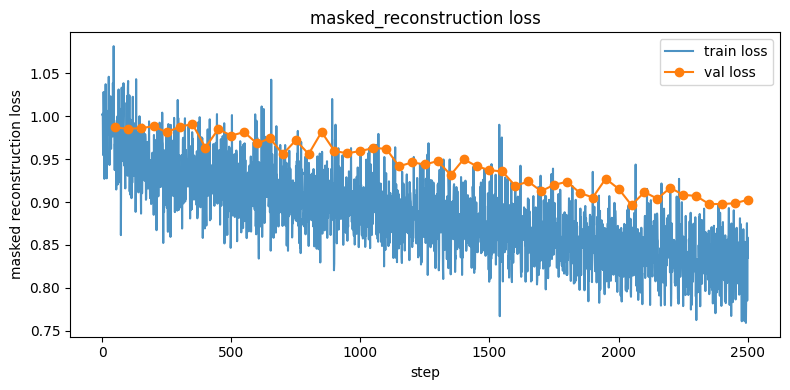

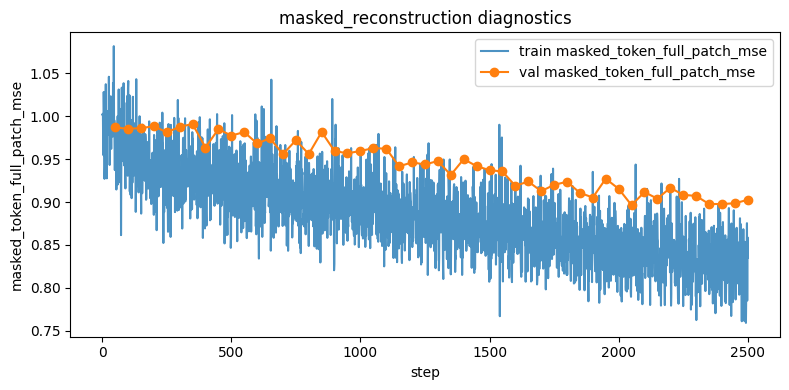

train_start_loss: 1.0020099878311157
train_final_loss: 0.8351088762283325
train_best_loss: 0.7591382265090942 at step 2493
val_best_loss: 0.8963664770126343 at step 2050
latest_train_masked_stats: {'prediction_mean': 0.004111205693334341, 'prediction_std': 0.40384939312934875, 'target_mean': 0.004137170035392046, 'target_std': 1.0020551681518555}
latest_val_masked_stats: {'prediction_mean': -0.0006220618961378932, 'prediction_std': 0.3460015207529068, 'target_mean': 0.01097069950774312, 'target_std': 1.000821316242218}
aux_metric_key: masked_token_full_patch_mse
plot_loss_path: /content/drive/MyDrive/utah_ssl/outputs/ssl_experiments/masked_reconstruction/colab_s5_masked_reconstruction_seg80_20260415T140843Z/loss_curve.png
plot_metric_path: /content/drive/MyDrive/utah_ssl/outputs/ssl_experiments/masked_reconstruction/colab_s5_masked_reconstruction_seg80_20260415T140843Z/masked_metric_curve.png
latest train record: {'event': 'train', 'step': 2500, 'elapsed_seconds': 1085.0198001861572, '

In [9]:
# Plot train / val curves for the active run.

SSL_PLOT_STATE = plot_ssl_training_history(SSL_RUN_STATE)
print("latest train record:", SSL_RUN_STATE["train_history"][-1] if SSL_RUN_STATE["train_history"] else None)
print("latest val record:", SSL_RUN_STATE["val_history"][-1] if SSL_RUN_STATE["val_history"] else None)


In [28]:
# Collapse monitor: early warnings for trivial masked reconstruction.

COLLAPSE_RATIO_THRESHOLD = 0.10
COLLAPSE_CONSECUTIVE_LOGS = 5
MSE_BASELINE = 1.0
BASELINE_MARGIN = 0.02
MSE_CHECK_STEP_K = 120

train_history = SSL_RUN_STATE.get("train_history", [])
if not train_history:
    print("No train history found in SSL_RUN_STATE.")
else:
    ratio_series = []
    for row in train_history:
        pred_std = float(row.get("masked_prediction_std", 0.0))
        target_std = float(row.get("masked_target_std", 0.0))
        if target_std <= 1e-8:
            ratio = float("inf")
        else:
            ratio = pred_std / target_std
        ratio_series.append((int(row.get("step", 0)), ratio))

    longest = 0
    current = 0
    first_alert_step = None
    for step, ratio in ratio_series:
        if ratio < COLLAPSE_RATIO_THRESHOLD:
            current += 1
            if first_alert_step is None and current >= COLLAPSE_CONSECUTIVE_LOGS:
                first_alert_step = step
        else:
            current = 0
        if current > longest:
            longest = current

    up_to_k = [row for row in train_history if int(row.get("step", 0)) <= MSE_CHECK_STEP_K]
    if up_to_k:
        best_loss_to_k = min(float(row.get("loss", float("inf"))) for row in up_to_k)
        mse_baseline_flag = best_loss_to_k >= (MSE_BASELINE - BASELINE_MARGIN)
    else:
        best_loss_to_k = float("nan")
        mse_baseline_flag = False

    latest_step = int(train_history[-1].get("step", 0))
    latest_ratio = ratio_series[-1][1] if ratio_series else float("nan")

    print(
        f"collapse_monitor: latest_step={latest_step} latest_ratio={latest_ratio:.4f} \
ratio_thresh={COLLAPSE_RATIO_THRESHOLD:.2f} longest_low_ratio_run={longest}"
    )
    print(
        f"collapse_monitor: best_loss_step<=K (K={MSE_CHECK_STEP_K}) = {best_loss_to_k:.4f}; \
baseline={MSE_BASELINE:.2f}, margin={BASELINE_MARGIN:.2f}"
    )

    alerts = []
    if first_alert_step is not None:
        alerts.append(
            f"ALERT: pred_std/target_std < {COLLAPSE_RATIO_THRESHOLD:.2f} for \
{COLLAPSE_CONSECUTIVE_LOGS} consecutive logs (first triggered at step {first_alert_step})."
        )
    if mse_baseline_flag:
        alerts.append(
            f"ALERT: masked MSE did not beat ~{MSE_BASELINE:.1f} baseline by step \
{MSE_CHECK_STEP_K} (best={best_loss_to_k:.4f})."
        )

    if alerts:
        print("\n".join(alerts))
    else:
        print("No collapse alerts triggered with current thresholds.")


collapse_monitor: latest_step=6500 latest_ratio=0.5024 ratio_thresh=0.10 longest_low_ratio_run=53
collapse_monitor: best_loss_step<=K (K=120) = 0.8763; baseline=1.00, margin=0.02
ALERT: pred_std/target_std < 0.10 for 5 consecutive logs (first triggered at step 8).


In [ ]:
# Optional: list saved SSL checkpoints for the active run.

import pandas as pd

CHECKPOINT_LIST_RUN_DIR = Path(ACTIVE_SSL_CHECKPOINT_RUN_DIR)
AVAILABLE_SSL_CHECKPOINTS = list_ssl_checkpoints(CHECKPOINT_LIST_RUN_DIR)
display(pd.DataFrame(AVAILABLE_SSL_CHECKPOINTS))


## Downstream Probe Workflow

These cells keep the same held-out `Brain2Text25` workflow as the other `s5` notebooks.
The main apples-to-apples frozen comparison is:

- pretrained masked-reconstruction encoder, frozen, linear probe
- random-init encoder, frozen, same linear probe


In [29]:
# Configure and preview the held-out Brain2Text25 probe split.

PROBE_SESSION_LIMIT = 8
PROBE_TARGET_SESSION_COUNT = 4
PROBE_BATCH_SIZE = 8
PROBE_BUDGET_SECONDS = 240
PROBE_MAX_STEPS = 400
PROBE_HEAD_LEARNING_RATE = 1e-3
ENCODER_LEARNING_RATE = 3e-4
PROBE_WEIGHT_DECAY = 1e-2

DOWNSTREAM_PROBE_CONFIG = DownstreamProbeConfig(
    enabled=True,
    seed=SEED,
    session_limit=PROBE_SESSION_LIMIT,
    target_session_count=PROBE_TARGET_SESSION_COUNT,
    probe_batch_size=PROBE_BATCH_SIZE,
    probe_budget_seconds=PROBE_BUDGET_SECONDS,
    max_probe_steps=PROBE_MAX_STEPS,
    probe_head_learning_rate=PROBE_HEAD_LEARNING_RATE,
    encoder_learning_rate=None,
    weight_decay=PROBE_WEIGHT_DECAY,
    probe_head_type="linear",
)

downstream_problem_preview = build_downstream_probe_problem(
    cache_root=Path(CACHE_CONTEXT.cache_root),
    probe_config=DOWNSTREAM_PROBE_CONFIG,
    feature_mode=FEATURE_MODE,
)
print("eligible_sessions:", len(downstream_problem_preview["eligible_entries"]))
print("preview_source_sessions:", [entry.session_base for entry in downstream_problem_preview["split"].train])
print("preview_target_sessions:", [entry.session_base for entry in downstream_problem_preview["split"].val])


eligible_sessions: 45
preview_source_sessions: ['t15.2024.07.21', 't15.2024.07.28', 't15.2025.01.10', 't15.2025.01.12']
preview_target_sessions: ['t15.2025.03.14', 't15.2025.03.16', 't15.2025.03.30', 't15.2025.04.13']


In [30]:
# Shared downstream experiment helpers.

import pandas as pd

FROZEN_LINEAR_PROBE_OVERRIDES = {"probe_head_type": "linear"}
QUICK_CONV1D_PROBE_OVERRIDES = {
    "probe_head_type": "conv1d",
    "probe_conv_hidden_size": HIDDEN_SIZE,
    "probe_conv_kernel_size": 3,
    "probe_budget_seconds": 120,
    "max_probe_steps": 50,
}
B2_LINEAR_PROBE_OVERRIDES = {
    "probe_head_type": "linear",
    "probe_head_learning_rate": PROBE_HEAD_LEARNING_RATE,
    "encoder_learning_rate": ENCODER_LEARNING_RATE,
    "weight_decay": PROBE_WEIGHT_DECAY,
    "probe_budget_seconds": 600,
    "max_probe_steps": 800,
}

def build_notebook_random_probe_state(*, seed_offset: int = 0):
    return build_random_init_probe_state(
        reference_config=DOWNSTREAM_PROBE_DEFAULT_STATE["checkpoint_config"],
        input_dim=DOWNSTREAM_PROBE_DEFAULT_STATE["input_dim"],
        seed=SEED + int(seed_offset),
        base_run_dir=DOWNSTREAM_PROBE_BASE_RUN_DIR,
    )

def display_probe_summaries(*summary_dicts):
    rows = [summary for summary in summary_dicts if summary is not None]
    if not rows:
        print("No summaries to display.")
    else:
        display(pd.DataFrame(rows))


In [32]:
# Recover the default SSL encoder and prepare reusable downstream probe state.

DOWNSTREAM_PROBE_DEFAULT_STATE = recover_downstream_probe_state(
    probe_config=DOWNSTREAM_PROBE_CONFIG,
    output_root=OUTPUT_ROOT,
    input_dim=FULL_DIM,
    default_checkpoint_config=SSL_TRAINING_CONFIG.checkpoint_config(),
    in_memory_model=SSL_RUN_STATE["model"] if "SSL_RUN_STATE" in globals() else None,
    current_checkpoint_path=Path(ACTIVE_SSL_CHECKPOINT_PATH),
    current_run_dir=Path(ACTIVE_SSL_CHECKPOINT_RUN_DIR),
)

DOWNSTREAM_PROBE_BASE_RUN_DIR = Path(DOWNSTREAM_PROBE_DEFAULT_STATE["base_run_dir"])
print("DOWNSTREAM_PROBE_ENCODER_SOURCE:", DOWNSTREAM_PROBE_DEFAULT_STATE["source"])
print("DOWNSTREAM_PROBE_BASE_RUN_DIR:", DOWNSTREAM_PROBE_BASE_RUN_DIR)
print("DOWNSTREAM_PROBE_CHECKPOINT_PATH:", DOWNSTREAM_PROBE_DEFAULT_STATE["checkpoint_path"])


DOWNSTREAM_PROBE_ENCODER_SOURCE: checkpoint
DOWNSTREAM_PROBE_BASE_RUN_DIR: /content/drive/MyDrive/utah_ssl/outputs/ssl_experiments/masked_reconstruction/colab_s5_masked_reconstruction_seg80_20260415T124714Z
DOWNSTREAM_PROBE_CHECKPOINT_PATH: /content/drive/MyDrive/utah_ssl/outputs/ssl_experiments/masked_reconstruction/colab_s5_masked_reconstruction_seg80_20260415T124714Z/checkpoint_final.pt


In [33]:
# Frozen SSL checkpoint linear probe.

SSL_CHECKPOINT_LINEAR_SUMMARY = run_downstream_probe(
    probe_state=DOWNSTREAM_PROBE_DEFAULT_STATE,
    probe_config=DOWNSTREAM_PROBE_CONFIG,
    cache_root=Path(CACHE_CONTEXT.cache_root),
    device=DEVICE,
    variant_prefix="ssl_checkpoint",
    artifact_prefix="ssl_checkpoint",
    train_encoder=False,
    probe_overrides=FROZEN_LINEAR_PROBE_OVERRIDES,
)
display_probe_summaries(SSL_CHECKPOINT_LINEAR_SUMMARY)


,model_variant,comparison_mode,probe_head_type,seed,probe_head_num_parameters,probe_head_learning_rate,encoder_learning_rate,weight_decay,train_encoder,adaptation_regime,...,top_substitution_pair_rate,probe_steps,probe_elapsed_seconds,checkpoint_source_used,checkpoint_path,feature_mode,run_dir,progress_log_path,alignment_stats_path,summary_path
0,ssl_checkpoint_linear_probe,ssl_checkpoint_linear_probe,linear,7,10537,0.001,None,0.01,False,A,...,0.024793,58,288.607081,checkpoint,/content/drive/MyDrive/utah_ssl/outputs/ssl_ex...,tx_only,/content/drive/MyDrive/utah_ssl/outputs/ssl_ex...,/content/drive/MyDrive/utah_ssl/outputs/ssl_ex...,/content/drive/MyDrive/utah_ssl/outputs/ssl_ex...,/content/drive/MyDrive/utah_ssl/outputs/ssl_ex...


In [ ]:
# Random-init frozen linear probe baseline.

RANDOM_INIT_FROZEN_STATE = build_notebook_random_probe_state(seed_offset=1000)
RANDOM_INIT_LINEAR_SUMMARY = run_downstream_probe(
    probe_state=RANDOM_INIT_FROZEN_STATE,
    probe_config=DOWNSTREAM_PROBE_CONFIG,
    cache_root=Path(CACHE_CONTEXT.cache_root),
    device=DEVICE,
    variant_prefix="random_init",
    artifact_prefix="random_init",
    train_encoder=False,
    probe_overrides=FROZEN_LINEAR_PROBE_OVERRIDES,
)
display_probe_summaries(SSL_CHECKPOINT_LINEAR_SUMMARY, RANDOM_INIT_LINEAR_SUMMARY)


In [ ]:
# Optional stronger frozen-head diagnostic.

SSL_CHECKPOINT_CONV1D_SUMMARY = run_downstream_probe(
    probe_state=DOWNSTREAM_PROBE_DEFAULT_STATE,
    probe_config=DOWNSTREAM_PROBE_CONFIG,
    cache_root=Path(CACHE_CONTEXT.cache_root),
    device=DEVICE,
    variant_prefix="ssl_checkpoint",
    artifact_prefix="ssl_checkpoint",
    train_encoder=False,
    probe_overrides=QUICK_CONV1D_PROBE_OVERRIDES,
)
display_probe_summaries(SSL_CHECKPOINT_CONV1D_SUMMARY)


In [ ]:
# Full fine-tuning from the masked SSL checkpoint.

SSL_CHECKPOINT_B2_SUMMARY = run_downstream_probe(
    probe_state=DOWNSTREAM_PROBE_DEFAULT_STATE,
    probe_config=DOWNSTREAM_PROBE_CONFIG,
    cache_root=Path(CACHE_CONTEXT.cache_root),
    device=DEVICE,
    variant_prefix="ssl_checkpoint_b2",
    artifact_prefix="ssl_checkpoint_b2",
    train_encoder=True,
    probe_overrides=B2_LINEAR_PROBE_OVERRIDES,
)
display_probe_summaries(SSL_CHECKPOINT_B2_SUMMARY)


In [ ]:
# Full fine-tuning from random initialization.

RANDOM_INIT_B2_STATE = build_notebook_random_probe_state(seed_offset=2000)
RANDOM_INIT_B2_SUMMARY = run_downstream_probe(
    probe_state=RANDOM_INIT_B2_STATE,
    probe_config=DOWNSTREAM_PROBE_CONFIG,
    cache_root=Path(CACHE_CONTEXT.cache_root),
    device=DEVICE,
    variant_prefix="random_init_b2",
    artifact_prefix="random_init_b2",
    train_encoder=True,
    probe_overrides=B2_LINEAR_PROBE_OVERRIDES,
)
display_probe_summaries(SSL_CHECKPOINT_B2_SUMMARY, RANDOM_INIT_B2_SUMMARY)


In [34]:
# Compact comparison table for the main summaries collected above.

MAIN_SUMMARIES = [
    globals().get("SSL_CHECKPOINT_LINEAR_SUMMARY"),
    globals().get("RANDOM_INIT_LINEAR_SUMMARY"),
    globals().get("SSL_CHECKPOINT_B2_SUMMARY"),
    globals().get("RANDOM_INIT_B2_SUMMARY"),
]
display_probe_summaries(*MAIN_SUMMARIES)


,model_variant,comparison_mode,probe_head_type,seed,probe_head_num_parameters,probe_head_learning_rate,encoder_learning_rate,weight_decay,train_encoder,adaptation_regime,...,top_substitution_pair_rate,probe_steps,probe_elapsed_seconds,checkpoint_source_used,checkpoint_path,feature_mode,run_dir,progress_log_path,alignment_stats_path,summary_path
0,ssl_checkpoint_linear_probe,ssl_checkpoint_linear_probe,linear,7,10537,0.001,None,0.01,False,A,...,0.024793,58,288.607081,checkpoint,/content/drive/MyDrive/utah_ssl/outputs/ssl_ex...,tx_only,/content/drive/MyDrive/utah_ssl/outputs/ssl_ex...,/content/drive/MyDrive/utah_ssl/outputs/ssl_ex...,/content/drive/MyDrive/utah_ssl/outputs/ssl_ex...,/content/drive/MyDrive/utah_ssl/outputs/ssl_ex...


In [ ]:
# TEMP: evaluate one session directly from rows_by_dataset (ignores train/val split maps).
import random
import numpy as np

from masked_ssl.cache import sample_base_segment, stack_segment_batch
from masked_ssl.training import evaluate_model

TARGET_DATASET = "brain2text24"
TARGET_SESSION = "t12.2022.08.18"
EVAL_BATCHES = 40
EVAL_SEED = 123

cfg = dict(SSL_RUN_STATE["config"])

all_rows = CACHE_CONTEXT.rows_by_dataset.get(TARGET_DATASET, [])
session_rows = [r for r in all_rows if r.session_id == TARGET_SESSION]
if len(session_rows) == 0:
    raise RuntimeError(f"No rows found in rows_by_dataset for {TARGET_DATASET}:{TARGET_SESSION}")

segment_bins = int(cfg["segment_bins"])
valid_rows = [r for r in session_rows if int(r.n_time_bins) >= segment_bins]
if len(valid_rows) == 0:
    raise RuntimeError(f"No valid rows with n_time_bins >= {segment_bins} for {TARGET_SESSION}")

weights = np.array([max(1, int(r.n_time_bins) - segment_bins + 1) for r in valid_rows], dtype=np.float64)
weights /= weights.sum()

class SingleSessionSampler:
    def __init__(self, cache_context, rows, probs, *, batch_size, segment_bins, seed):
        self.cache_context = cache_context
        self.rows = rows
        self.probs = probs
        self.batch_size = int(batch_size)
        self.segment_bins = int(segment_bins)
        self.py_rng = random.Random(int(seed))
        self.np_rng = np.random.default_rng(int(seed))

    def sample_batch(self, batch_size=None):
        bs = self.batch_size if batch_size is None else int(batch_size)
        idx = self.np_rng.choice(len(self.rows), size=bs, replace=True, p=self.probs)
        samples = [
            sample_base_segment(
                self.cache_context,
                self.rows[int(i)],
                segment_bins=self.segment_bins,
                py_rng=self.py_rng,
            )
            for i in np.atleast_1d(idx)
        ]
        return stack_segment_batch(samples)

sampler = SingleSessionSampler(
    CACHE_CONTEXT,
    valid_rows,
    weights,
    batch_size=int(cfg["batch_size"]),
    segment_bins=segment_bins,
    seed=EVAL_SEED,
)

metrics = evaluate_model(
    SSL_RUN_STATE["model"],
    sampler,
    num_batches=int(EVAL_BATCHES),
    device=DEVICE,
    mask_unit=str(cfg["mask_unit"]),
    mask_token_placement=str(cfg["mask_token_placement"]),
    mask_ratio=float(cfg["mask_ratio"]),
    span_length_min=int(cfg["span_length_min"]),
    span_length_max=int(cfg["span_length_max"]),
    num_spans_mode=str(cfg["num_spans_mode"]),
    allow_bin_fractional_overlap=bool(cfg["allow_bin_fractional_overlap"]),
)

print(f"toy_eval dataset={TARGET_DATASET} session={TARGET_SESSION} (split-agnostic)")
for k in ["loss", "masked_token_full_patch_mse", "actual_mask_ratio", "masked_token_ratio", "masked_prediction_std", "masked_target_std"]:
    print(f"{k}: {metrics[k]:.6f}")


RuntimeError: No rows found in rows_by_dataset for brain2text24:t12.2022.08.18

## Notes

This notebook intentionally omits the contrastive retrieval diagnostics from the older `s5` notebooks.
For this experiment, the primary scorecard is held-out frozen phoneme transfer, with masked-reconstruction loss used as a training diagnostic.
